In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
caminho = r"C:\Projetos\LearningDataAnalysis\dados\microdados_enem_2018\DADOS\MICRODADOS_ENEM_2018.csv"

In [3]:
microdadosEnem = pd.read_csv(caminho, sep=";", encoding='ISO-8859-1')

In [11]:
microdadosEnem.columns.values

<StringArray>
[          'NU_INSCRICAO',                 'NU_ANO',        'TP_FAIXA_ETARIA',
                'TP_SEXO',        'TP_ESTADO_CIVIL',            'TP_COR_RACA',
       'TP_NACIONALIDADE',        'TP_ST_CONCLUSAO',        'TP_ANO_CONCLUIU',
              'TP_ESCOLA',              'TP_ENSINO',           'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC',       'NO_MUNICIPIO_ESC',              'CO_UF_ESC',
              'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',     'TP_LOCALIZACAO_ESC',
        'TP_SIT_FUNC_ESC',     'CO_MUNICIPIO_PROVA',     'NO_MUNICIPIO_PROVA',
            'CO_UF_PROVA',            'SG_UF_PROVA',         'TP_PRESENCA_CN',
         'TP_PRESENCA_CH',         'TP_PRESENCA_LC',         'TP_PRESENCA_MT',
            'CO_PROVA_CN',            'CO_PROVA_CH',            'CO_PROVA_LC',
            'CO_PROVA_MT',             'NU_NOTA_CN',             'NU_NOTA_CH',
             'NU_NOTA_LC',             'NU_NOTA_MT',        'TX_RESPOSTAS_CN',
        'TX_RESPOSTAS_CH',        'TX_

In [40]:
q001e002Dicionario = {
'A': 'Nunca Estudou',
'B': 'Não completou a 4ª série/5º ano do Ensino Fundamental.',
'C': 'Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.',
'D': 'Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.',
'E': 'Completou o Ensino Médio, mas não completou a Faculdade.',
'F': 'Completou a Faculdade, mas não completou a Pós-graduação.',
'G': 'Completou a Pós-graduação.',
'H': 'Não sei.'
}

Text(0.02, 0.65, 'A : Nunca Estudou\nB : Não completou a 4ª série/5º ano do Ensino Fundamental.\nC : Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.\nD : Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.\nE : Completou o Ensino Médio, mas não completou a Faculdade.\nF : Completou a Faculdade, mas não completou a Pós-graduação.\nG : Completou a Pós-graduação.\nH : Não sei.\n')

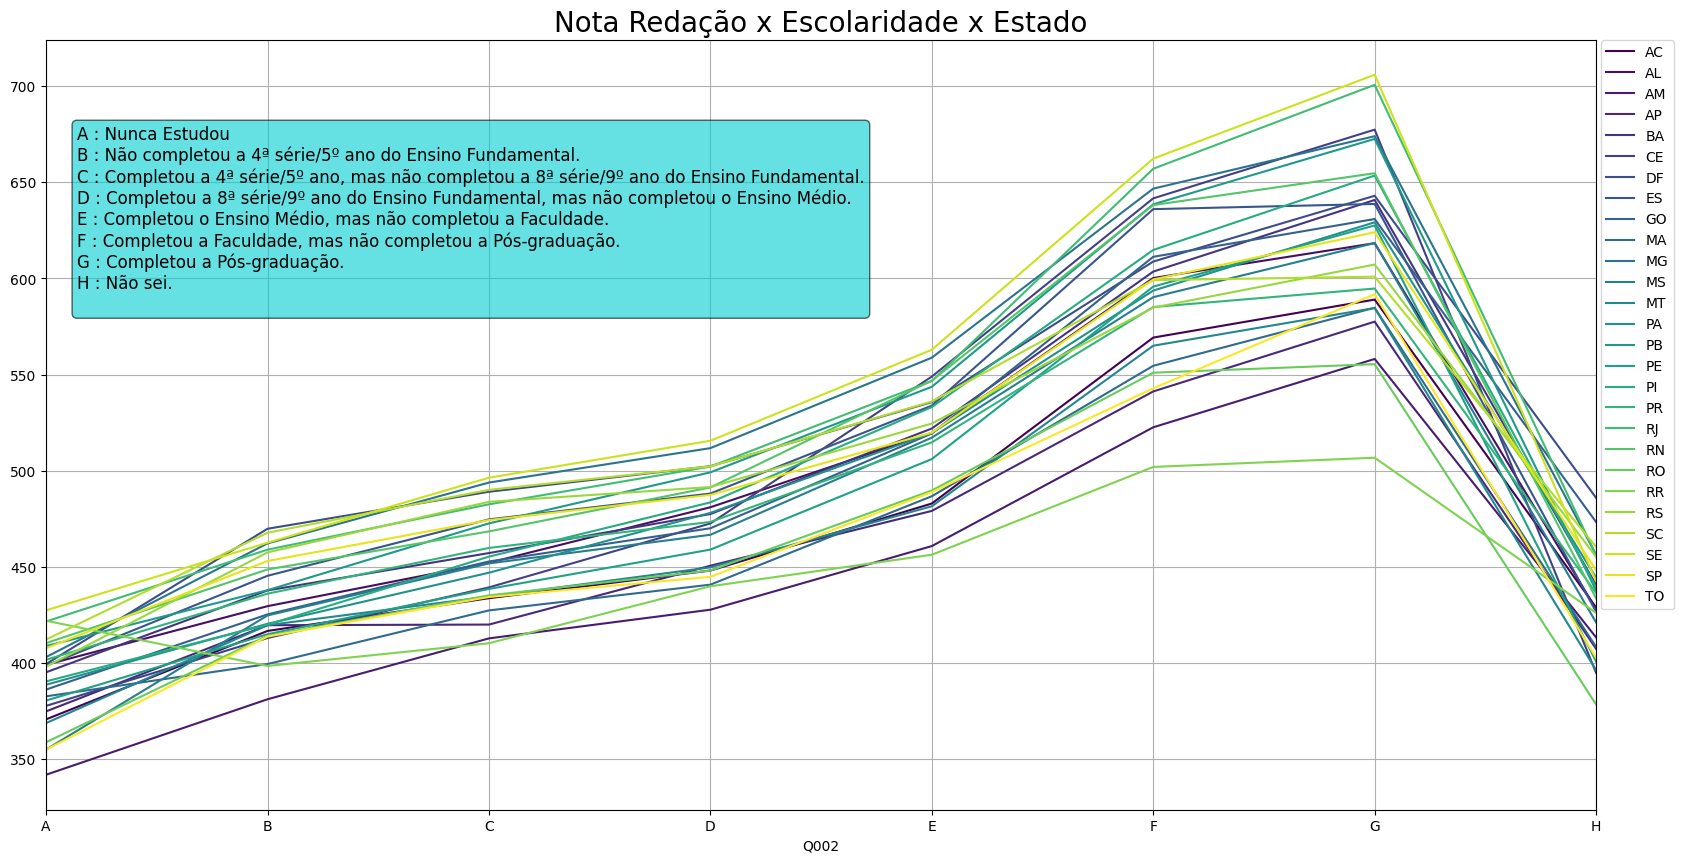

In [61]:
#fig, ax = plt.subplots(figsize=(25, 15))
#plt.suptitle('Nota Redação x Escolaridade x Estado')


ax = microdadosEnem.filter(items = ['SG_UF_ESC','Q002', 'NU_NOTA_REDACAO'])\
            .groupby(['Q002', 'SG_UF_ESC'])\
            .mean().sort_values(by='NU_NOTA_REDACAO', ascending=False)\
            .unstack().plot(figsize=(20, 10), colormap='viridis', grid=True)

ax.set_title('Nota Redação x Escolaridade x Estado', fontsize=20)
ax.margins(x=0)
#ax.legend(bbox_to_anchor=(1.05, 1), loc=0, borderaxespad=0.)

handles, labels = ax.get_legend_handles_labels()

edited_labels = [re.search(',\\s(.+?)\\)', label).group(1) for label in labels]
#[edited_labels = [re.search(r',\s(.+?)\)', label).group(1) for label in labels], pode ser feito assim também para extrair o texto que deseja]
ax.legend(edited_labels, bbox_to_anchor=(1.05, 1), loc=0, borderaxespad=0.)

textdictQ002 = ""
for key, value in q001e002Dicionario.items():
    textdictQ002 += f"{key} : {value}\n"

ax.text(0.02, 0.65, textdictQ002, transform=ax.transAxes, fontsize=12, color = 'black', bbox={'boxstyle':'round', 'facecolor':'darkturquoise', 'alpha':0.6}) 
